# Zadania z przetwarzania tekstów z zajęć projektowych

## WordCloud

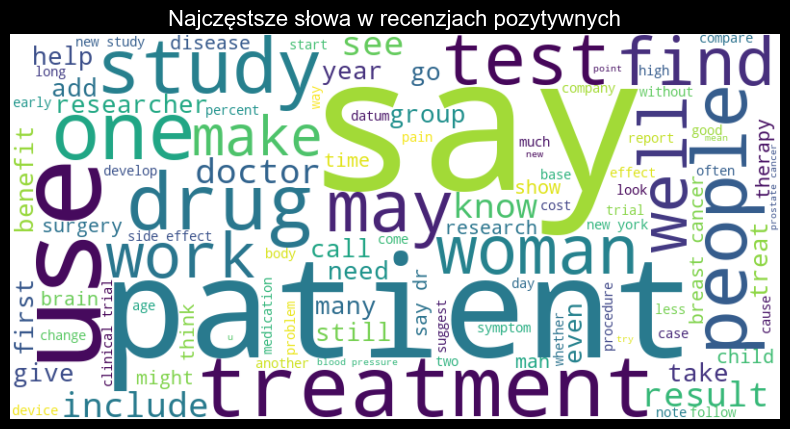

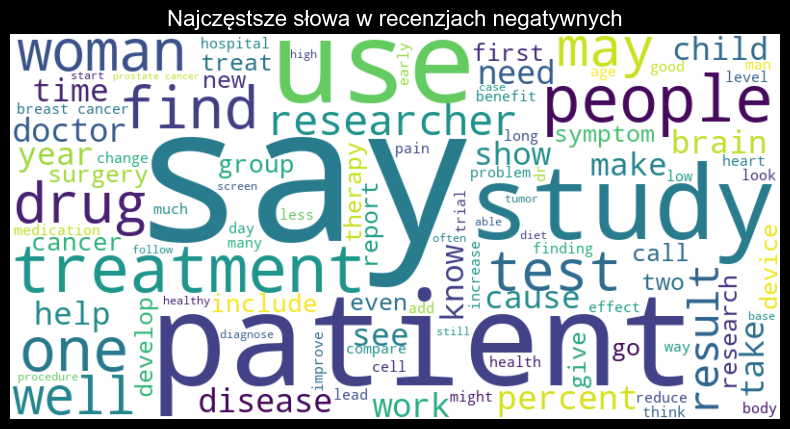

In [1]:
# --- 1a. WordCloud dla wizualizacji najczęstszych słów ---
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import pandas as pd

df_clean = pd.read_csv('HealthStory_cleaned.csv')

# Pozytywne recenzje
positive_text = " ".join(df_clean[df_clean['rating'] >= 3]['text'].astype(str))
# Negatywne recenzje
negative_text = " ".join(df_clean[df_clean['rating'] < 3]['text'].astype(str))

# Funkcja do generowania i wyświetlania wordclouda
def plot_wordcloud(text, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        colormap='viridis'
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

plot_wordcloud(positive_text, "Najczęstsze słowa w recenzjach pozytywnych")
plot_wordcloud(negative_text, "Najczęstsze słowa w recenzjach negatywnych")


## N-gramy

In [2]:
from nltk.util import ngrams
from collections import Counter

def top_ngrams(p_tokens, n=2, k=10):
  ng = ngrams(p_tokens, n)
  c = Counter(ng)
  return c.most_common(k)

In [4]:
texts  = df_clean['text'].astype(str)
def tokenize(p_texts):
    r_tokens = []
    for text in texts:
        r_tokens.extend(text.split())
    return r_tokens

tokens = tokenize(texts)

In [5]:
print("\nTop 10 bigramów:")
for pair, c in top_ngrams(tokens, n=2, k=10):
  print(f"{pair} -> {c}")


Top 10 bigramów:
('breast', 'cancer') -> 763
('say', 'dr') -> 718
('side', 'effect') -> 669
('new', 'york') -> 584
('new', 'study') -> 583
('prostate', 'cancer') -> 478
('clinical', 'trial') -> 460
('blood', 'pressure') -> 434
('heart', 'attack') -> 430
('study', 'publish') -> 387


In [6]:
print("\nTop 10 trigramów:")
for pair, c in top_ngrams(tokens, 3, 10):
  print(f"{pair} -> {c}")


Top 10 trigramów:
('food', 'drug', 'administration') -> 256
('new', 'england', 'journal') -> 153
('en', 'espa', 'ol') -> 152
('new', 'york', 'city') -> 151
('england', 'journal', 'medicine') -> 150
('new', 'york', 'times') -> 150
('high', 'blood', 'pressure') -> 142
('continue', 'read', 'main') -> 140
('read', 'main', 'story') -> 140
('heart', 'attack', 'stroke') -> 132


## Najbardziej reprezentatywne słowa - `log_odds`

In [7]:
import math

positive_texts = df_clean[df_clean['rating'] >= 3]['text'].astype(str)
negative_texts = df_clean[df_clean['rating'] < 3]['text'].astype(str)

pos_tokens = tokenize(positive_texts)
neg_tokens = tokenize(negative_texts)

pos_freq = Counter(pos_tokens)
neg_freq = Counter(neg_tokens)

In [8]:
def relative_freq(counter):
  total = sum(counter.values())
  return { w : (c/total if total else 0.0) for w, c in counter.items() }

rf_pos = relative_freq(pos_freq)
rf_neg = relative_freq(neg_freq)

In [9]:
def log_odds(c_pos, t_pos, c_neg, t_neg, alpha=1.0):
  return math.log((c_pos + alpha) / (t_pos - c_pos + alpha)) - math.log((c_neg + alpha) / (t_neg - c_neg + alpha))

In [10]:
tpos = sum(pos_freq.values())
tneg = sum(neg_freq.values())
vocab = set(pos_freq) | set(neg_freq)

scores = []
for w in vocab:
  cp, cn = pos_freq.get(w, 0), neg_freq.get(w, 0)
  lo = log_odds(cp, tpos, cn, tneg, alpha=1.0)
  scores.append((w, cp, cn, rf_pos.get(w, 0.0), rf_neg.get(w, 0.0), lo))

scores_sorted_pos = sorted(scores, key=lambda x: x[5], reverse=True)[:10]
scores_sorted_neg = sorted(scores, key=lambda x: x[5])[:10]

In [11]:
def print_stats(scores, title):
  print(f'Najbardziej reprezentatywne słowa - {title} (log_odds):')
  for w, cp, cn, rf_pos, rf_neg, lo in scores:
    print(f'{w:<15} pos= {cp}, neg= {cn}, rf_pos= {rf_pos:.3f}, rf_neg= {rf_neg:.3f}, log_odds= {lo:.3f}')

In [12]:
print_stats(scores_sorted_pos, 'pozytywne')
print()
print_stats(scores_sorted_neg, 'negatywne')

Najbardziej reprezentatywne słowa - pozytywne (log_odds):
quietly         pos= 5, neg= 5, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
salvageable     pos= 1, neg= 1, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
lucas           pos= 5, neg= 5, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
participating   pos= 2, neg= 2, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
economical      pos= 1, neg= 1, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
midpoint        pos= 2, neg= 2, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
studied         pos= 1, neg= 1, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
pruthi          pos= 2, neg= 2, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
txa             pos= 23, neg= 23, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
terrorist       pos= 3, neg= 3, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000

Najbardziej reprezentatywne słowa - negatywne (log_odds):
quietly         pos= 5, neg= 5, rf_pos= 0.000, rf_neg= 0.000, log_odds= 0.000
salvageable     pos= 1,

## Podobieństwo tekstów (dla 10 tekstów)

In [13]:
from sklearn. feature_extraction.text import TfidfVectorizer
import numpy as np

corpus = df_clean['text'].astype(str).head(10)
vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1,2), min_df=1)
X = vectorizer.fit_transform(corpus)

vocab = np.array(vectorizer.get_feature_names_out())
print("Kształt macierzy TF-IDF:", X.shape)

global_weights = np.asarray(X.sum(axis=0)).ravel()
top_idx = np.argsort(-global_weights) [:20]
df_top = pd.DataFrame({
    "term": vocab[top_idx],
    "sum_tfidf": global_weights[top_idx]
})

df_top

Kształt macierzy TF-IDF: (10, 4281)


,term,sum_tfidf
0,say,0.842363
1,cancer,0.629223
2,alzheimer,0.581365
3,patient,0.528080
4,study,0.497885
5,woman,0.470329
6,peanut,0.469894
7,disease,0.464233
8,people,0.404318
9,treatment,0.389900


### Podobieństwo cosinusowe

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(X)
pd.DataFrame(cos_sim, index=[f"Dokument {i+1}" for i in range(len(corpus))],
             columns=[f"Dokument {i+1}" for i in range(len(corpus))])

,Dokument 1,Dokument 2,Dokument 3,Dokument 4,Dokument 5,Dokument 6,Dokument 7,Dokument 8,Dokument 9,Dokument 10
Dokument 1,1.000000,0.023661,0.042513,0.030517,0.046127,0.075455,0.034672,0.046593,0.197366,0.048008
Dokument 2,0.023661,1.000000,0.045444,0.079029,0.051459,0.027086,0.022186,0.030077,0.022324,0.041105
Dokument 3,0.042513,0.045444,1.000000,0.021114,0.066000,0.051187,0.043820,0.043776,0.022711,0.071504
Dokument 4,0.030517,0.079029,0.021114,1.000000,0.038745,0.040884,0.035833,0.056907,0.039651,0.047558
Dokument 5,0.046127,0.051459,0.066000,0.038745,1.000000,0.055874,0.064852,0.141943,0.048138,0.083959
Dokument 6,0.075455,0.027086,0.051187,0.040884,0.055874,1.000000,0.082659,0.061515,0.062854,0.078336
Dokument 7,0.034672,0.022186,0.043820,0.035833,0.064852,0.082659,1.000000,0.067988,0.037820,0.072196
Dokument 8,0.046593,0.030077,0.043776,0.056907,0.141943,0.061515,0.067988,1.000000,0.038209,0.068429
Dokument 9,0.197366,0.022324,0.022711,0.039651,0.048138,0.062854,0.037820,0.038209,1.000000,0.048858
Dokument 10,0.048008,0.041105,0.071504,0.047558,0.083959,0.078336,0.072196,0.068429,0.048858,1.000000


### Miara Jaccarda

In [18]:
corpus = list(corpus)
token_sets = [set(doc.split()) for doc in corpus]

def jaccard(a, b):
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 0.0

J = np.zeros((len(corpus), len(corpus)))
for i in range(len(corpus)):
    for j in range(len(corpus)):
        J[i,j] = jaccard(token_sets[i], token_sets[j])

pd.DataFrame(J, index=[f"Dokument {i+1}" for i in range(len(corpus))],
columns=[f"Dokument {i+1}" for i in range(len(corpus))])

,Dokument 1,Dokument 2,Dokument 3,Dokument 4,Dokument 5,Dokument 6,Dokument 7,Dokument 8,Dokument 9,Dokument 10
Dokument 1,1.000000,0.069686,0.097561,0.105802,0.127820,0.115578,0.084112,0.110818,0.128920,0.115530
Dokument 2,0.069686,1.000000,0.051020,0.132780,0.061170,0.050802,0.045570,0.075581,0.062257,0.056974
Dokument 3,0.097561,0.051020,1.000000,0.055016,0.116049,0.082524,0.081206,0.110236,0.079470,0.112994
Dokument 4,0.105802,0.132780,0.055016,1.000000,0.089005,0.078947,0.066998,0.105714,0.094340,0.083984
Dokument 5,0.127820,0.061170,0.116049,0.089005,1.000000,0.112033,0.144033,0.132450,0.124324,0.162116
Dokument 6,0.115578,0.050802,0.082524,0.078947,0.112033,1.000000,0.117886,0.116740,0.111111,0.134454
Dokument 7,0.084112,0.045570,0.081206,0.066998,0.144033,0.117886,1.000000,0.111814,0.094148,0.130081
Dokument 8,0.110818,0.075581,0.110236,0.105714,0.132450,0.116740,0.111814,1.000000,0.096317,0.124138
Dokument 9,0.128920,0.062257,0.079470,0.094340,0.124324,0.111111,0.094148,0.096317,1.000000,0.096838
Dokument 10,0.115530,0.056974,0.112994,0.083984,0.162116,0.134454,0.130081,0.124138,0.096838,1.000000


## NER

In [23]:
import spacy
import stanza

nlp_spacy = spacy.load('en_core_web_sm')

stanza.download("en")
nlp_stanza = stanza.Pipeline(lang="en", preprocessors="tokenize,pos,ner")

2026-01-07 20:29:01 INFO: Downloaded file to C:\Users\Kuba\stanza_resources\resources.json
2026-01-07 20:29:01 INFO: Downloading default packages for language: en (English) ...
2026-01-07 20:29:02 INFO: File exists: C:\Users\Kuba\stanza_resources\en\default.zip
2026-01-07 20:29:07 INFO: Finished downloading models and saved to C:\Users\Kuba\stanza_resources
2026-01-07 20:29:07 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-01-07 20:29:07 INFO: Downloaded file to C:\Users\Kuba\stanza_resources\resources.json
2026-01-07 20:29:09 INFO: Loading these models for language: en (English):
| Processor    | Package                   |
--------------------------------------------
| tokenize     | combined                  |
| mwt          | combined                  |
| pos          | combined_charlm           |
| lemma        | combined_nocharlm         |
| constituency | ptb3-revised_charlm       |
| depparse     | combined_charlm           |
| sentiment    | sstplus_charlm            |
| ner          | ontonotes-ww-multi_charlm |

2026-01-07 20:29:09 INFO: Using device: cpu
2026-01-07 20:29:09 INFO: Loading: tokenize
2026-01-07 20:29:09 INFO: Loading: mwt
2026-01-07 20:29:09 INFO: Loading: pos
2026-01-07 20:29:12 INFO: Loading: lemma
2026-01-07 20:29:13 INFO: Loading: constituency
2026-01-07 20:29:13 INFO: Loading: depparse
2026-01-07 20:29:14 INFO: Loading: sentiment
2026-01-07 20:29:14 INFO: Loading: ner


In [29]:
texts = pd.read_csv('HealthStory_combined.csv')
texts = texts['text'].astype(str).sample(2)

### Spacy

In [30]:
def extract_ner_spacy(texts):
    entities = []
    for text in texts:
        doc = nlp_spacy(text)
        print(" === Tekst === ")
        print(text)
        print(" --- Encje (spaCy) --- ")
        for ent in doc.ents:
            print(f"{ent.text:30s} -> {ent.label_}")
            entities.append((ent.text, ent.label_))
        print()
    return entities

all_entities = extract_ner_spacy(texts)

ent_counter = Counter(all_entities)
rows = [
    {"ent_text": text, "ent_label": label, "freq": freq}
    for (text, label), freq in ent_counter.items()
]

df_ner_spacy = pd.DataFrame(rows).sort_values("freq", ascending=False)
df_ner_spacy

 === Tekst === 
LONDON (Reuters) - A hormone called DHEA and mostly secreted by the adrenal glands may be able to help women who are going through menopause and could also give them better sex lives, a study found on Tuesday.

Italian researchers writing in the journal of the International Menopause Society, Climacteric, said they had found the first robust evidence that low doses of DHEA can help sexual function and menopausal symptoms, suggesting it may one day become an alternative to hormone replacement therapy (HRT).

But they stressed that the trial was small, so far larger studies are needed to confirm the results.

“We must bear in mind that this is a pilot study with a small sample,” Anna Fenton, co-editor of Climacteric, said in commentary on the work. “We can’t yet say that this study means that DHEA is a viable alternative to HRT, but ... we should be looking to do larger studies to confirm these initial results.”

DHEA, or dehydroepiandrosterone, is a natural steroid hormo

,ent_text,ent_label,freq
47,FDA,ORG,16
31,Max,PERSON,12
37,DMD,ORG,11
32,Rowan,PERSON,6
9,HRT,ORG,5
...,...,...,...
113,Sandy Walsh,PERSON,1
114,Matthew Eckler,PERSON,1
115,RBC Capital Markets,ORG,1
116,nearly two,CARDINAL,1


In [31]:
def anonymize_with_spacy(text):
    doc = nlp_spacy(text)

    ents = [(ent.start_char, ent.end_char, ent.label_) for ent in doc.ents]
    ents_sorted = sorted(ents, key=lambda x: x[0])

    result = []
    last_idx = 0
    for start, end, label in ents_sorted:
        result.append(text[last_idx: start])
        result.append(f"[{label}]")
        last_idx = end


    result.append(text[last_idx: ])
    return "".join(result)

for t in texts:
    print("Oryginalny:", t)
    print("Po anonimizacji: ", anonymize_with_spacy(t))
    print()

Oryginalny: LONDON (Reuters) - A hormone called DHEA and mostly secreted by the adrenal glands may be able to help women who are going through menopause and could also give them better sex lives, a study found on Tuesday.

Italian researchers writing in the journal of the International Menopause Society, Climacteric, said they had found the first robust evidence that low doses of DHEA can help sexual function and menopausal symptoms, suggesting it may one day become an alternative to hormone replacement therapy (HRT).

But they stressed that the trial was small, so far larger studies are needed to confirm the results.

“We must bear in mind that this is a pilot study with a small sample,” Anna Fenton, co-editor of Climacteric, said in commentary on the work. “We can’t yet say that this study means that DHEA is a viable alternative to HRT, but ... we should be looking to do larger studies to confirm these initial results.”

DHEA, or dehydroepiandrosterone, is a natural steroid hormone m

### Stanza

In [32]:
def extract_ner_stanza(texts):
    entities = []
    for text in texts:
        print(" === Tekst === ")
        print(text)
        doc = nlp_stanza(text)
        print(" --- POS + NER (Stanza) --- ")

        for sent in doc.sentences:
            for token in sent.tokens:
                word = token.words[0] # UWAGA! POS jest w words
                pos = word.upos
                ner = token.ner # UWAGA! NER jest w tokens
                print(f"{token.text:20s} POS={pos:6s} NER={ner}")

        print()

        for sent in doc.sentences:
            for token in sent.tokens:
                if token.ner != "0":
                    entities.append((token.text, token.ner))

    return entities

all_entities_stanza = extract_ner_stanza(texts)

ent_counter_stanza = Counter(all_entities_stanza)
rows_stanza = [
    {"ent_text": text, "ent_label": label, "freq": freq}
    for (text, label), freq in ent_counter_stanza.items()
]

df_ner_stanza = pd.DataFrame(rows_stanza).sort_values("freq", ascending=False)
df_ner_stanza

 === Tekst === 
LONDON (Reuters) - A hormone called DHEA and mostly secreted by the adrenal glands may be able to help women who are going through menopause and could also give them better sex lives, a study found on Tuesday.

Italian researchers writing in the journal of the International Menopause Society, Climacteric, said they had found the first robust evidence that low doses of DHEA can help sexual function and menopausal symptoms, suggesting it may one day become an alternative to hormone replacement therapy (HRT).

But they stressed that the trial was small, so far larger studies are needed to confirm the results.

“We must bear in mind that this is a pilot study with a small sample,” Anna Fenton, co-editor of Climacteric, said in commentary on the work. “We can’t yet say that this study means that DHEA is a viable alternative to HRT, but ... we should be looking to do larger studies to confirm these initial results.”

DHEA, or dehydroepiandrosterone, is a natural steroid hormo

,ent_text,ent_label,freq
34,",",O,142
40,.,O,133
13,the,O,126
35,a,O,72
19,to,O,59
...,...,...,...
952,uncertainty,O,1
951,sons,O,1
950,Until,O,1
949,more,I-DATE,1


In [33]:
def anonymize_with_stanza(text):
    doc = nlp_stanza(text)
    spans = []

    for sent in doc.sentences:
        current_start = None
        current_end = None
        current_type = None

        for token in sent.tokens:
            ner = token.ner

            if ner == "O":
                if current_type is not None:
                    spans.append((current_start, current_end, current_type) )
                    current_start = current_end = current_type = None
                continue

            parts = ner.split("-")
            prefix = parts[0]
            ent_type = parts[-1]

            if prefix in ("B", "S", "U"):
                if current_type is not None:
                    spans.append((current_start, current_end, current_type) )

                current_start = token.start_char
                current_end = token.end_char
                current_type = ent_type

                if prefix in ("S", "U"):
                    spans.append((current_start, current_end, current_type))
                    current_start = current_end = current_type = None

            elif prefix in ("I", "E", "L"):
                if current_type == ent_type and current_start is not None:
                    current_end = token.end_char

                    if prefix in ("E", "L"):
                        spans.append((current_start, current_end, current_type))
                        current_start = current_end = current_type = None
                else:
                    spans.append((current_start, current_end, ent_type))
                    current_start = current_end = current_type = None

        if current_type is not None:
            spans.append((current_start, current_end, current_type))
            current_start = current_end = current_type = None


    spans_sorted = sorted(spans, key=lambda x: x[0])

    result = []
    last_idx = 0
    for start, end, label in spans_sorted:
        result.append(text[last_idx: start])
        result.append(f"[{label}]")
        last_idx = end

    result.append(text[last_idx: ])
    return "".join(result)

In [34]:
for t in texts:
    print("Oryginalny:", t)
    print("Po anonimizacji: ", anonymize_with_stanza(t))
    print()

Oryginalny: LONDON (Reuters) - A hormone called DHEA and mostly secreted by the adrenal glands may be able to help women who are going through menopause and could also give them better sex lives, a study found on Tuesday.

Italian researchers writing in the journal of the International Menopause Society, Climacteric, said they had found the first robust evidence that low doses of DHEA can help sexual function and menopausal symptoms, suggesting it may one day become an alternative to hormone replacement therapy (HRT).

But they stressed that the trial was small, so far larger studies are needed to confirm the results.

“We must bear in mind that this is a pilot study with a small sample,” Anna Fenton, co-editor of Climacteric, said in commentary on the work. “We can’t yet say that this study means that DHEA is a viable alternative to HRT, but ... we should be looking to do larger studies to confirm these initial results.”

DHEA, or dehydroepiandrosterone, is a natural steroid hormone m

## Modelowanie tematów

In [35]:
texts = pd.read_csv('HealthStory_combined.csv')
texts = texts['text'].astype(str)

In [37]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Ustawienie losowości dla powtarzalności wyników
RANDOM_STATE = 42

In [38]:
max_features = 5000
min_df = 5

count_vectorizer = CountVectorizer(
    max_features=max_features,
    min_df=min_df,
    stop_words='english'
)

X_counts = count_vectorizer.fit_transform(texts)
print("Macierz częstości:", X_counts.shape)

tfidf_vectorizer = TfidfVectorizer(
    max_features=max_features,
    min_df=min_df,
    stop_words='english'
)

X_tfidf = tfidf_vectorizer.fit_transform(texts)
print("Macierz TF-IDF:", X_tfidf.shape)

Macierz częstości: (1638, 5000)
Macierz TF-IDF: (1638, 5000)


In [39]:
def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Temat {topic_idx}:")
        top_indices = topic.argsort() [ :-n_top_words - 1 :-1]
        top_terms = [feature_names[i] for i in top_indices]
        print(" " + " ".join(top_terms))

### LDA

In [40]:
n_topics = 3

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=RANDOM_STATE,
    learning_method='batch'
)

lda_topics = lda.fit_transform(X_counts)
print("Macierz przydziału dokumentów do tematów (LDA):", lda_topics.shape)

print("Top słowa w tematach LDA:")
feature_names_counts = count_vectorizer.get_feature_names_out()
print_top_words(lda, feature_names_counts, n_top_words=10)

Macierz przydziału dokumentów do tematów (LDA): (1638, 3)
Top słowa w tematach LDA:
Temat 0:
 said says study people brain patients treatment children pain health
Temat 1:
 cancer said patients study new women dr test percent breast
Temat 2:
 study said people risk heart drug women disease new researchers


### NMF

In [41]:
nmf = NMF(
    n_components=n_topics,
    random_state=RANDOM_STATE,
    init='nndsvda',
    max_iter=200
)

nmf_topics = nmf.fit_transform(X_tfidf)
print("Macierz przydziału dokumentów do tematów (NMF):", nmf_topics.shape)

print("Top słowa w tematach NMF:")
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
print_top_words(nmf, feature_names_tfidf, n_top_words=10)

Macierz przydziału dokumentów do tematów (NMF): (1638, 3)
Top słowa w tematach NMF:
Temat 0:
 said patients study heart says people drug brain treatment blood
Temat 1:
 cancer women breast prostate screening risk men said test study
Temat 2:
 nan value know test alzheimer sister kim psa save wearing


## Architektura *Tranformer* - koder

In [55]:
from transformers import pipeline, BertTokenizer

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Device set to use cpu


In [66]:
texts = pd.read_csv('HealthStory_cleaned.csv')
rating = texts['rating'].map(lambda x : "positive" if x > 3 else "negative").head(1)
sentences = texts['text'].astype(str).head(1)
sentences = list(sentences)

results = classifier(sentences)
for i, (s, r) in enumerate(zip(sentences, results)):
    print(f"Zdanie: {s[:50]}")
    print(f"→ Etykieta: {r['label']}, confidence: {r['score']:.3f}")
    print(f"→ Real: {rating[i]}")

Zdanie: scientist find unexpected use virtual reality head
→ Etykieta: NEGATIVE, confidence: 0.986
→ Real: negative
